/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46353 instead
  warnings.warn(


Dask client ready: <Client: 'tcp://127.0.0.1:43169' processes=1 threads=2, memory=22.35 GiB>


/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 19.12 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 19.28 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Send

Saved RAW CSV → /data0/balaji24/data/derived/seasonal_precip_skagit_2014_2020_ALL_raw.csv
[info] Found duplicate (dataset,year,season) rows; coalescing with mean:
            dataset  year season          mm
56  HRRR (stitched)  2015    DJF  191.825623
57  HRRR (stitched)  2015    DJF  354.280792
61  HRRR (stitched)  2016    DJF  361.946533
65  HRRR (stitched)  2016    DJF  433.515839
63  HRRR (stitched)  2016    JJA         NaN
67  HRRR (stitched)  2016    JJA  133.944489
62  HRRR (stitched)  2016    MAM         NaN
66  HRRR (stitched)  2016    MAM  281.242096
64  HRRR (stitched)  2016    SON         NaN
68  HRRR (stitched)  2016    SON  560.314453
69  HRRR (stitched)  2017    DJF  156.230621
73  HRRR (stitched)  2017    DJF  314.523804
Saved CSV → /data0/balaji24/data/derived/seasonal_precip_skagit_2014_2020_ALL.csv
                   dataset  year season          mm
0  CONUS404 (hourly→daily)  2014    DJF  139.240479
1                     ORNL  2014    DJF  609.083496
2             

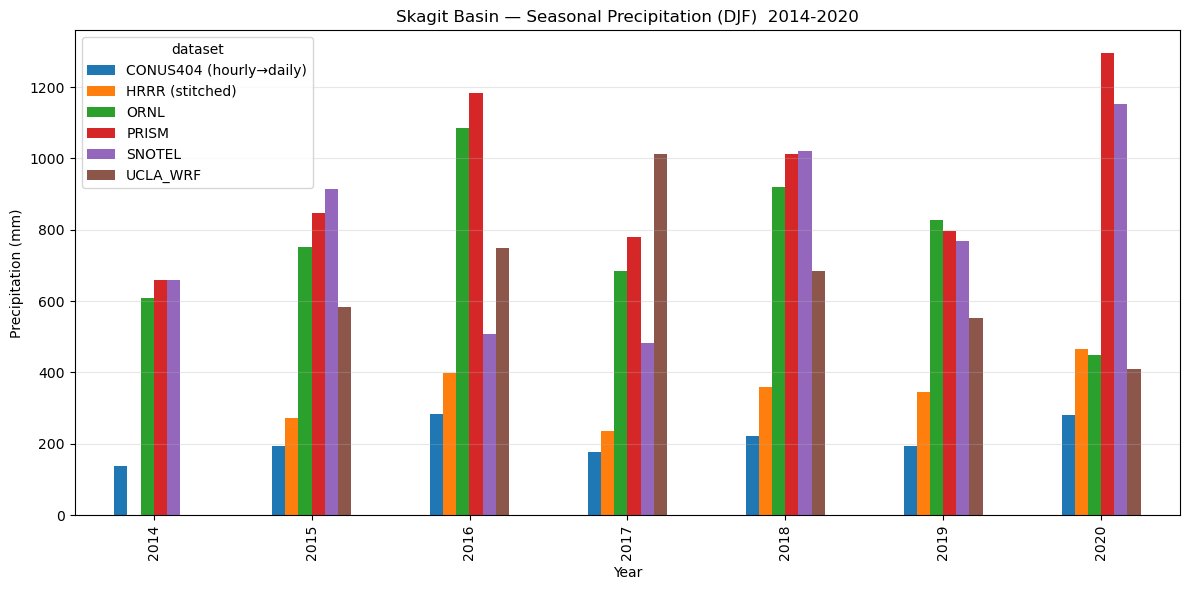

Saved plot → /data0/balaji24/data/derived/seasonal_precip_skagit_2014_2020_MAM.png


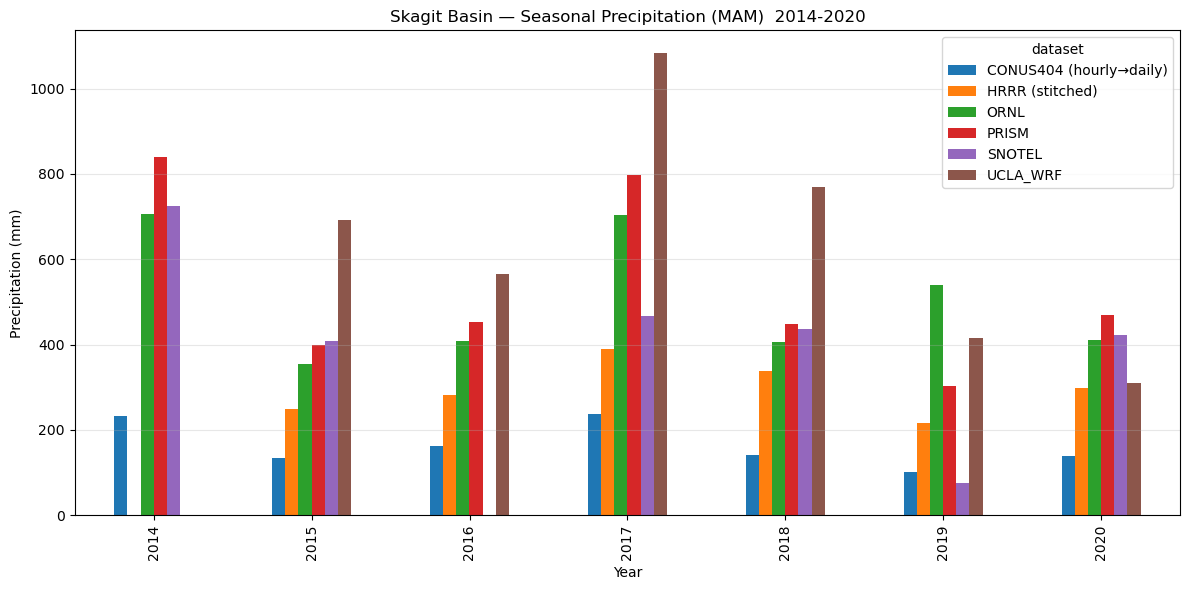

Saved plot → /data0/balaji24/data/derived/seasonal_precip_skagit_2014_2020_JJA.png


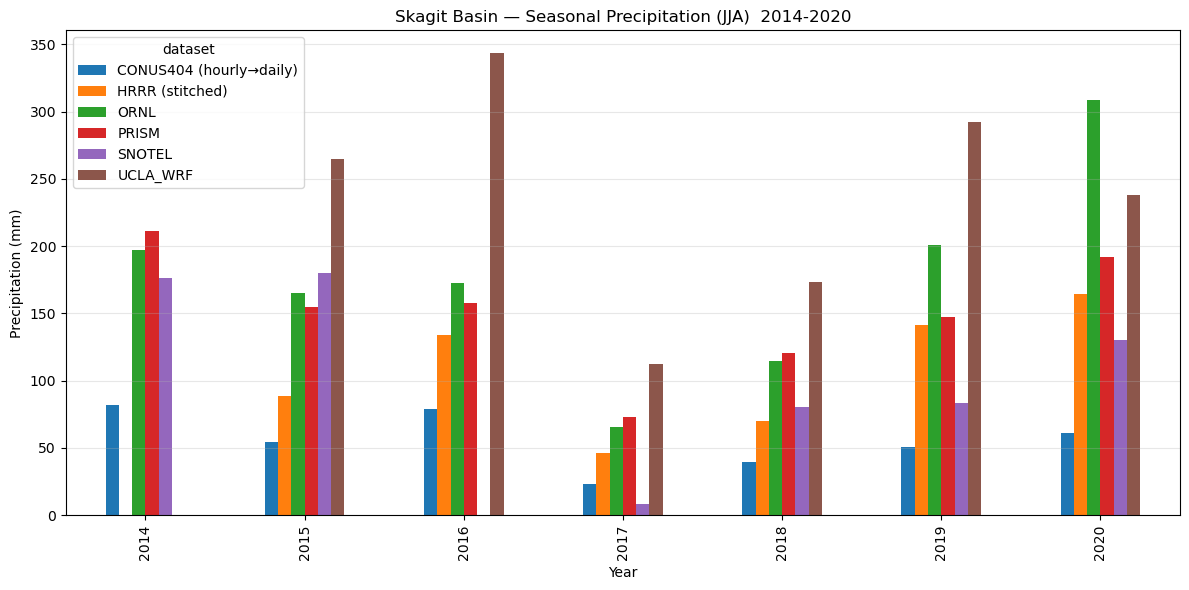

Saved plot → /data0/balaji24/data/derived/seasonal_precip_skagit_2014_2020_SON.png


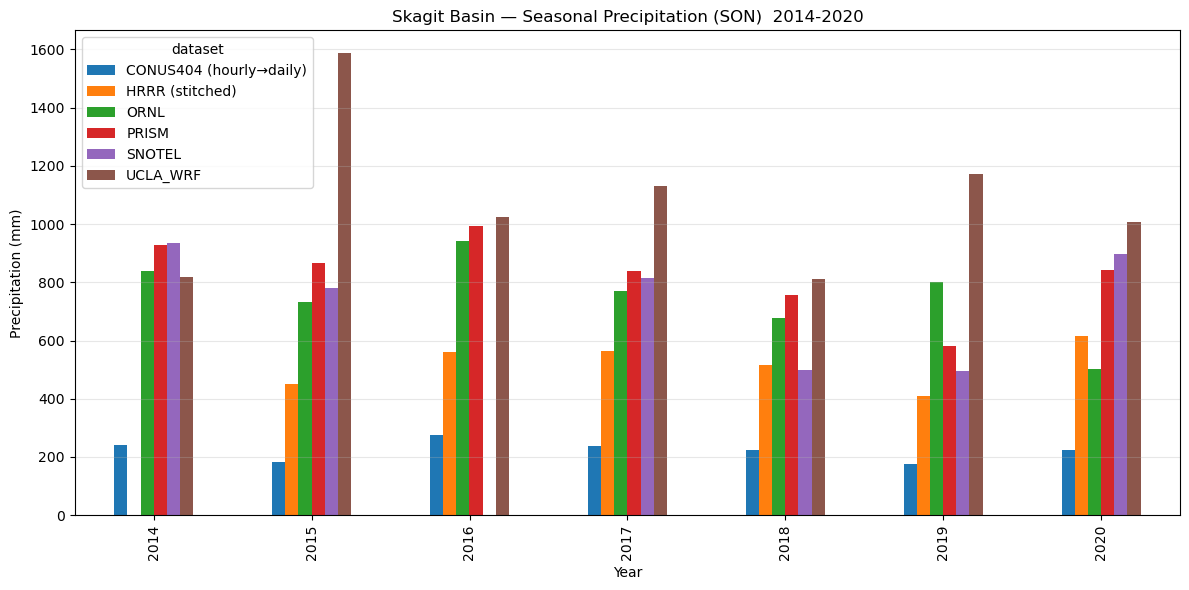

Done.


In [6]:
# ============================
# Skagit Basin — Seasonal Precip (mm) by dataset (2014–2020)
# 4 grouped-bar plots: DJF / MAM / JJA / SON
# SAFE MODE: Dask memory caps + disk spill + lazy opens + float32 downcasts
# ============================

# ---- Safe Dask setup: memory caps + spill to /data0 ----
from dask.distributed import Client, LocalCluster
import dask, os, pathlib, gc

TMP = pathlib.Path("/data0/balaji24/dask-tmp")
TMP.mkdir(parents=True, exist_ok=True)
os.environ["DASK_TEMPORARY_DIRECTORY"] = str(TMP)

cluster = LocalCluster(
    n_workers=1,                 # avoid multi-proc memory amplification
    threads_per_worker=2,
    memory_limit="24GB",         # keep comfortably under node RAM; adjust if needed
    processes=True,
)
client = Client(cluster)
dask.config.set({
    "distributed.worker.memory.target": 0.60,
    "distributed.worker.memory.spill": 0.70,
    "distributed.worker.memory.pause": 0.85,
    "distributed.worker.memory.terminate": 0.95,
    "array.slicing.split_large_chunks": True,
    "optimization.fuse.active": False,
})
print("Dask client ready:", client)

# ---- Rest of imports ----
import json, re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO  = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2020

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # expect many *_HRRR_data.zarr months
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # annual zarrs
P_SNOTEL_DIR = BASE / "snotel"                   # monthly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year
PNNL_GEO     = BASE / "PNNL" / "SERDP6km.geo_em.d01.nc"

# our derived CONUS404 Zarr (from your previous step)
P_CONUS_DERIVED = BASE / "derived" / "conus404_skagit_precip_daily.zarr"

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT / "seasonal_precip_skagit_2014_2020_ALL.csv"
RAW_CSV_OUT = OUT / "seasonal_precip_skagit_2014_2020_ALL_raw.csv"
PLOT_PREFIX = OUT / "seasonal_precip_skagit_2014_2020"

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    """Open Zarr lazily with reasonable chunks to limit RAM."""
    try:
        return xr.open_zarr(p, consolidated=True, chunks="auto")
    except Exception:
        return xr.open_zarr(p, consolidated=False, chunks="auto")

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def _load_boundary_geom():
    from shapely.geometry import shape, Polygon, LinearRing
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if isinstance(obj, dict) and "type" in obj:
        if obj["type"] == "FeatureCollection":
            return shape(obj["features"][0]["geometry"])
        elif obj["type"] == "Feature":
            return shape(obj["geometry"])
        else:
            return shape(obj)
    elif isinstance(obj, dict) and {"lon","lat"} <= obj.keys():
        pts = list(zip(obj["lon"], obj["lat"]))
        if pts[0] != pts[-1]:
            pts.append(pts[0])
        return Polygon(LinearRing(pts))
    raise ValueError("Unrecognized boundary format")

def skagit_mask(ds_with_latlon):
    try:
        import regionmask, geopandas as gpd
    except Exception:
        return None

    lat_name, lon_name = find_lat_lon_names(ds_with_latlon)
    if not (lat_name and lon_name):
        return None

    def _to_2d(arr):
        if "time" in arr.dims:
            arr = arr.isel(time=0)
        for d in list(arr.dims):
            if arr.sizes[d] == 1:
                arr = arr.isel({d: 0})
        while arr.ndim > 2:
            extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
            if not extra: break
            arr = arr.isel({extra[0]: 0})
        return arr

    lon = _to_2d(ds_with_latlon[lon_name])
    lat = _to_2d(ds_with_latlon[lat_name])

    from shapely.geometry import shape
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    geom = shape(obj["features"][0]["geometry"]) if obj.get("type")=="FeatureCollection" \
        else shape(obj["geometry"]) if obj.get("type")=="Feature" else shape(obj)

    try:
        regions = regionmask.Regions.from_geopandas(
            gpd.GeoDataFrame({"name":["Skagit"]}, geometry=[geom], crs="EPSG:4326"),
            names="name",
        )
    except AttributeError:
        regions = regionmask.Regions(outlines=[geom], names=["Skagit"], numbers=[0], name="Skagit")

    m = regions.mask(lon, lat)   # NaN outside, 0 inside
    return m.isnull() == False   # True inside

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"
    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    is_cum = force_cumulative or any(k in name for k in ["prec_acc_nc","rainnc","rainc","acc"]) \
             or ("cumulative" in units)

    da = ensure_time_sorted_unique(da)
    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)
        inc = xr.concat([da.isel(time=slice(0,1))*0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc
    return da

def basin_mean(da, grid_ds=None):
    time_dim = next((d for d in da.dims if np.issubdtype(da[d].dtype, np.datetime64)), "time")
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da
    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    mask = skagit_mask(host)
    if (mask is None) or (set(mask.dims) != set(spatial)):
        return da.mean(spatial, skipna=True)
    w = xr.where(mask, 1.0, np.nan)
    return (da * w).mean(spatial, skipna=True)

# ---- Seasonal grouping helpers ----
SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]

def season_and_year(time_index):
    """Return pandas Series (season, season_year) where DJF's Dec is assigned to next year's DJF."""
    t = pd.DatetimeIndex(time_index.values)
    month = t.month
    # wrap in Series for vectorized isin()
    season = np.where(pd.Series(month).isin([12,1,2]), "DJF",
             np.where(pd.Series(month).isin([3,4,5]), "MAM",
             np.where(pd.Series(month).isin([6,7,8]), "JJA", "SON")))
    year = t.year + (month == 12).astype(int)   # Dec → next year's DJF
    return pd.Series(season, index=t), pd.Series(year, index=t)

def seasonal_sum_mm(daily_series, year_min, year_max):
    """Sum daily mm into seasonal totals with DJF aligned to J/F year."""
    daily = ensure_time_sorted_unique(daily_series)
    s, y = season_and_year(daily["time"])
    daily = daily.assign_coords(season=(("time",), s.values),
                                season_year=(("time",), y.values))
    seas = daily.groupby(["season_year","season"]).sum("time")
    return seas.sel(season_year=slice(year_min, year_max))

# --------- Extra helpers for HRRR ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run","init","forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step","lead","forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)
    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k:0 for k in da.dims if k not in ("time","step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

# ---------------- Collect + compute seasonal rows ----------------
rows = []

def _seas_to_rows(dsname, seas, year_min, year_max):
    """Compute small seasonal table and append rows (memory-safe)."""
    # Small; safe to realize to numpy for fast scalar extraction
    seas = seas.astype("float32").compute()
    for yr in range(year_min, year_max+1):
        for ss in SEASON_ORDER:
            try:
                val = float(seas.sel(season_year=yr, season=ss).values)
                rows.append({"dataset": dsname, "year": yr, "season": ss, "mm": val})
            except Exception:
                pass

# ORNL (Daymet: mm/day)
if P_ORNL_DIR.exists():
    parts = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if parts:
        dso = xr.concat([safe_open_zarr(p) for p in parts], dim="time",
                        join="outer", coords="minimal", compat="override")
        try:
            if "prcp" in dso:
                da = ensure_time_sorted_unique(dso["prcp"])  # mm/day
                bm = basin_mean(da, grid_ds=dso).astype("float32")
                seas = seasonal_sum_mm(bm, YEAR_MIN, YEAR_MAX)
                _seas_to_rows("ORNL", seas, YEAR_MIN, YEAR_MAX)
        finally:
            del dso; gc.collect()

# PRISM (daily mm)
if P_PRISM_DIR.exists():
    parts = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if parts:
        dsp = xr.concat([safe_open_zarr(p) for p in parts], dim="time",
                        join="outer", coords="minimal", compat="override")
        try:
            v = next((v for v in ["ppt","precip","prcp"] if v in dsp), None)
            if v:
                da = ensure_time_sorted_unique(dsp[v])  # mm/day
                bm = basin_mean(da, grid_ds=dsp).astype("float32")
                seas = seasonal_sum_mm(bm, YEAR_MIN, YEAR_MAX)
                _seas_to_rows("PRISM", seas, YEAR_MIN, YEAR_MAX)
        finally:
            del dsp; gc.collect()

# HRRR (monthly stitched → hourly → daily)
months = sorted(P_HRRR_DIR.glob("*.zarr"))
if months:
    monthly = [p for p in months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        parts = [p for p in monthly if p.name.startswith(f"{yr}-")]
        if not parts:
            continue
        dsets = [safe_open_zarr(p) for p in parts]
        try:
            ds = xr.concat(dsets, dim="time", join="outer", coords="minimal").sortby("time")
            var = "tp" if "tp" in ds else ("apcp" if "apcp" in ds else None)
            if var:
                hourly_mm = hrrr_hourly_precip_mm(ds, var=var).astype("float32")
                daily     = hourly_mm.resample(time="1D").sum()
                bm        = basin_mean(daily, grid_ds=ds).astype("float32")
                seas      = seasonal_sum_mm(bm, YEAR_MIN, YEAR_MAX)
                _seas_to_rows("HRRR (stitched)", seas, YEAR_MIN, YEAR_MAX)
        finally:
            for d in dsets:
                try: d.close()
                except: pass
            del dsets
            try: del ds
            except: pass
            gc.collect()

# UCLA WRF (yearly; RAINNC/RAINC cumulative)
if P_WRF_DIR.exists():
    for z in sorted(P_WRF_DIR.glob("*.zarr")):
        m = re.search(r"(\d{4})", z.name)
        yr = int(m.group(1)) if m else None
        if (yr is None) or (yr < YEAR_MIN-1) or (yr > YEAR_MAX+1):
            continue
        dsw = safe_open_zarr(z)
        try:
            v_nc = next((n for n in ["RAINNC","rainnc"] if n in dsw), None)
            v_c  = next((n for n in ["RAINC","rainc"] if n in dsw), None)
            if not (v_nc or v_c):
                continue
            total = None
            for vv in [v_nc, v_c]:
                if vv:
                    inc = to_incremental_mm(dsw[vv], force_cumulative=True).astype("float32")
                    total = inc if total is None else total + inc
            total = ensure_time_sorted_unique(total)
            daily = total.resample(time="1D").sum()
            bm = basin_mean(daily, grid_ds=dsw).astype("float32")
            seas = seasonal_sum_mm(bm, YEAR_MIN, YEAR_MAX)
            _seas_to_rows("UCLA_WRF", seas, YEAR_MIN, YEAR_MAX)
        finally:
            del dsw; gc.collect()

# SNOTEL (monthly; aggregate by season directly)
if P_SNOTEL_DIR.exists():
    snotel_months = sorted(P_SNOTEL_DIR.glob("**/*.zarr"))
    if snotel_months:
        dss = xr.concat([safe_open_zarr(p) for p in snotel_months], dim="time",
                        join="outer", coords="minimal", compat="override")
        try:
            vS = next((v for v in ["PRECIPITATION","ppt","prcp","ACCUMULATED PRECIPITATION","accum_precip"] if v in dss), None)
            if vS:
                da = dss[vS]
                units = str(da.attrs.get("units","")).lower()
                if not units or units in {"inch","in","inches"} or float(da.max()) <= 10.0:
                    da = (da * 25.4).assign_attrs(units="mm")
                site_dims = list(da.dims)
                site_dim = "site" if "site" in site_dims else None
                if site_dim in da.dims:
                    da = da.mean(site_dim, skipna=True).astype("float32")
                da = ensure_time_sorted_unique(da)
                # seasonal sum from monthly timestamps
                s, y = season_and_year(da["time"])
                df_s = pd.DataFrame({"mm": da.values.astype("float32"),
                                     "season": s.values, "season_year": y.values})
                g = df_s.groupby(["season_year","season"], as_index=False)["mm"].sum()
                for _, r in g.iterrows():
                    yv, ss, val = int(r["season_year"]), str(r["season"]), float(r["mm"])
                    if (YEAR_MIN <= yv <= YEAR_MAX) and (ss in SEASON_ORDER):
                        rows.append({"dataset":"SNOTEL", "year": yv, "season": ss, "mm": val})
        finally:
            del dss; gc.collect()

# CONUS404 (derived daily mm)
if P_CONUS_DERIVED.exists():
    dsc = safe_open_zarr(P_CONUS_DERIVED)
    try:
        if "precip_basin_daily" in dsc:
            series = dsc["precip_basin_daily"].sel(time=slice(f"{YEAR_MIN-1}-12-01", f"{YEAR_MAX}-12-31")).astype("float32")
        elif "precip_daily" in dsc:
            grid = dsc["precip_daily"].sel(time=slice(f"{YEAR_MIN-1}-12-01", f"{YEAR_MAX}-12-31")).astype("float32")
            if "basin_mask" in dsc:
                w = dsc["basin_mask"].astype("float32")
                w = w / w.sum()
                series = (grid * w).sum(["y","x"], skipna=True)
            else:
                series = grid.mean(["y","x"], skipna=True)
        else:
            series = None

        if series is not None:
            seas = seasonal_sum_mm(series, YEAR_MIN, YEAR_MAX)
            _seas_to_rows("CONUS404 (hourly→daily)", seas, YEAR_MIN, YEAR_MAX)
    finally:
        del dsc; gc.collect()

# ---------------- Results & Plots ----------------
df = pd.DataFrame(rows)

# Save raw (debug)
df.sort_values(["season","year","dataset"]).to_csv(RAW_CSV_OUT, index=False)
print("Saved RAW CSV →", RAW_CSV_OUT)

# Collapse any accidental duplicates (e.g., overlaps) — guarantees one row per key
dups = df[df.duplicated(["dataset","year","season"], keep=False)]
if not dups.empty:
    print("[info] Found duplicate (dataset,year,season) rows; coalescing with mean:")
    print(dups.sort_values(["dataset","year","season"]).head(12))

df = (df.groupby(["dataset","year","season"], as_index=False, sort=False)["mm"]
        .mean()
        .sort_values(["season","year","dataset"])
        .reset_index(drop=True))

# Save cleaned
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)
print(df.head())

# Make 4 grouped bar charts: one per season
for ss in SEASON_ORDER:
    dfs = (df[df["season"] == ss]
           .pivot_table(index="year", columns="dataset", values="mm", aggfunc="mean")
           .sort_index())
    ax = dfs.plot(kind="bar", figsize=(12,6))
    ax.set_title(f"Skagit Basin — Seasonal Precipitation ({ss})  {YEAR_MIN}-{YEAR_MAX}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Precipitation (mm)")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    out_png = f"{PLOT_PREFIX}_{ss}.png"
    plt.savefig(out_png, dpi=160)
    print(f"Saved plot → {out_png}")
    plt.show()

print("Done.")

/tmp/ipykernel_6120/1427639748.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved detailed box plot → /data0/balaji24/data/derived/seasonal_precip_skagit_2014_2020_DJF_BOX_detailed.png


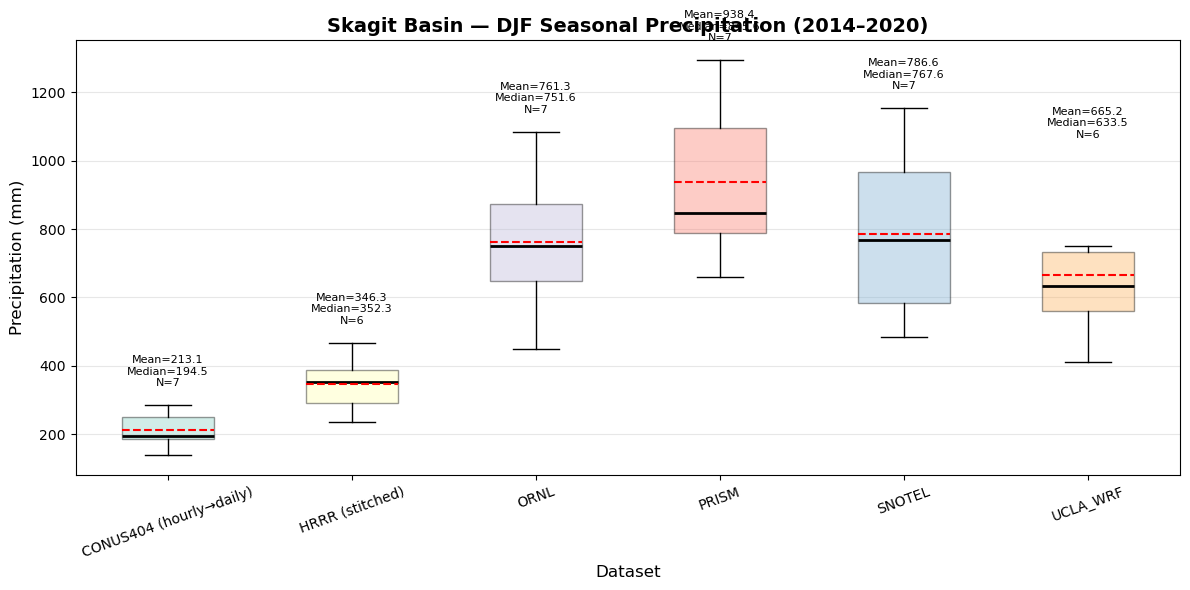

/tmp/ipykernel_6120/1427639748.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved detailed box plot → /data0/balaji24/data/derived/seasonal_precip_skagit_2014_2020_MAM_BOX_detailed.png


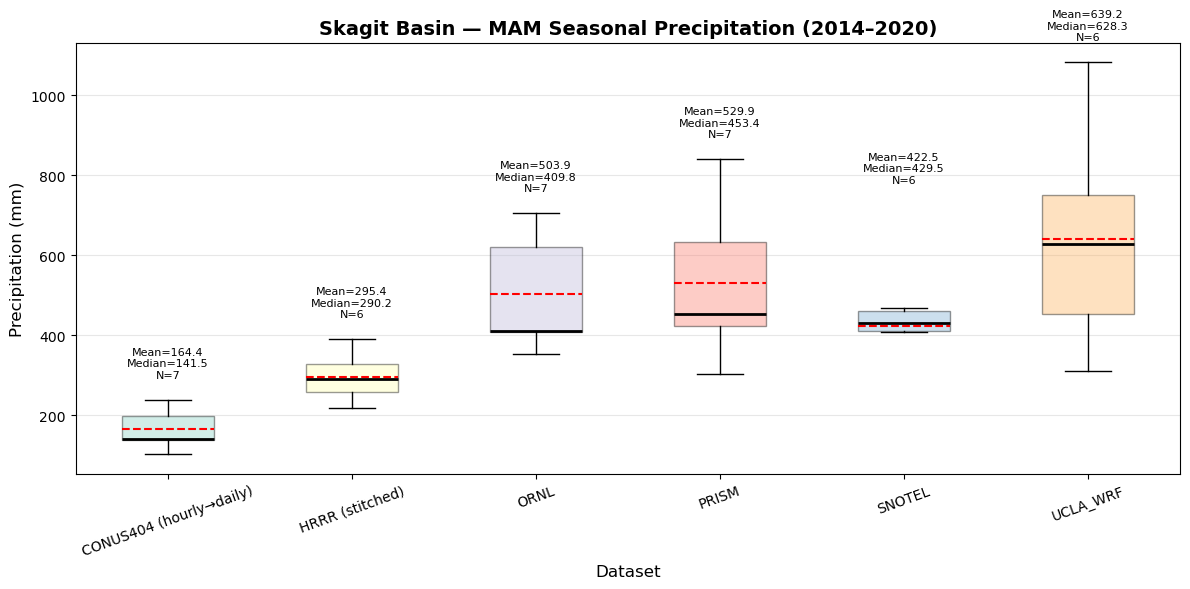

/tmp/ipykernel_6120/1427639748.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved detailed box plot → /data0/balaji24/data/derived/seasonal_precip_skagit_2014_2020_JJA_BOX_detailed.png


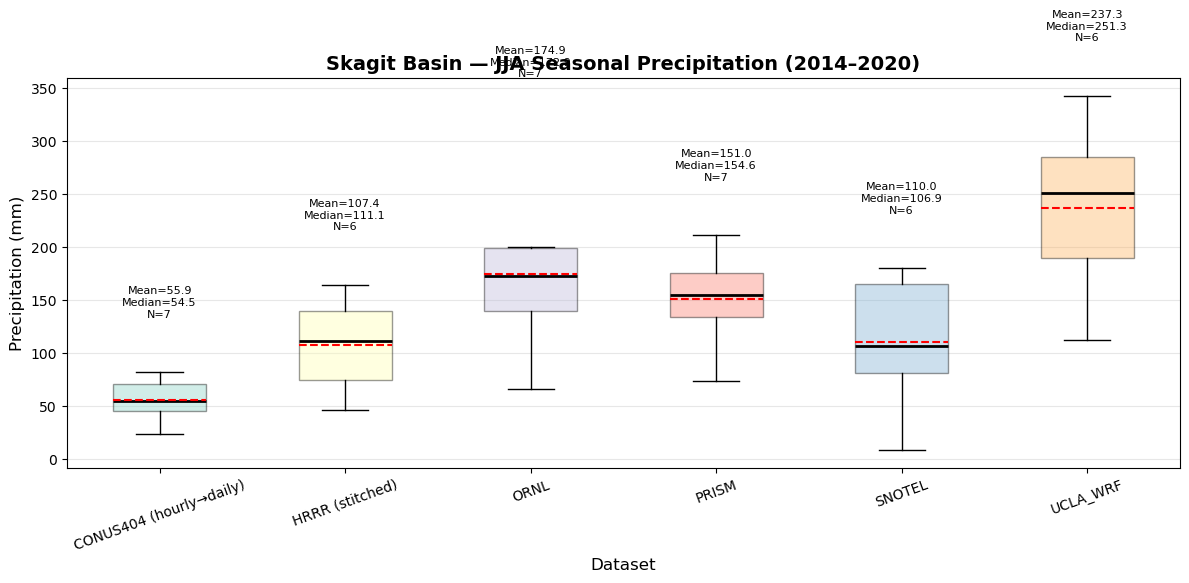

/tmp/ipykernel_6120/1427639748.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved detailed box plot → /data0/balaji24/data/derived/seasonal_precip_skagit_2014_2020_SON_BOX_detailed.png


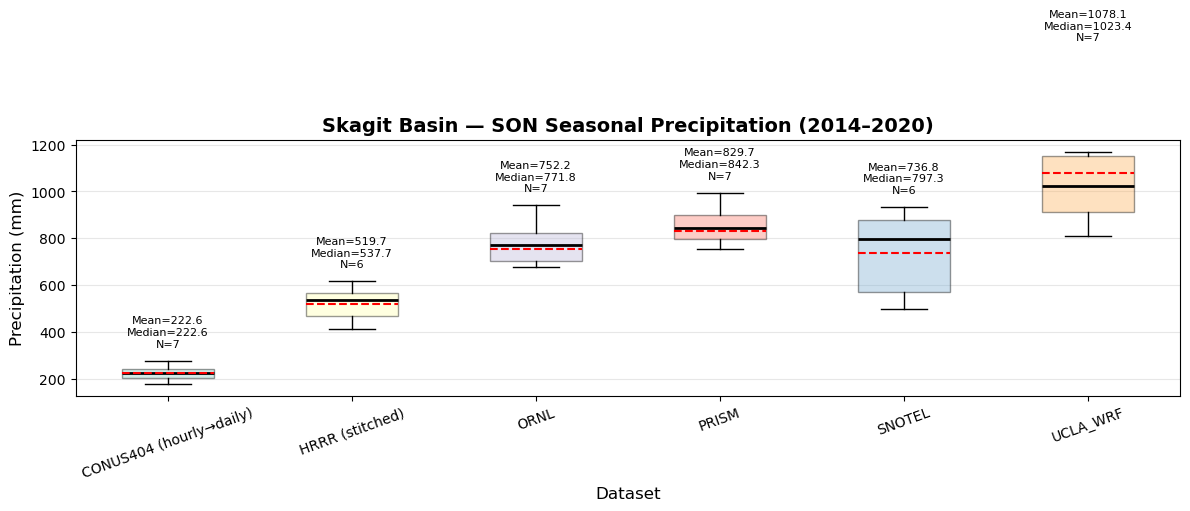

In [9]:
# ============================
# Enhanced box plots — Seasonal precipitation per dataset (No Seaborn)
# ============================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# reload df if needed
if 'df' not in locals():
    df = pd.read_csv("/data0/balaji24/data/derived/seasonal_precip_skagit_2014_2020_ALL.csv")

# soft pastel color palette for boxes
colors = [
    "#8dd3c7", "#ffffb3", "#bebada", "#fb8072",
    "#80b1d3", "#fdb462", "#b3de69", "#fccde5"
]

plt.style.use("default")

for ss in SEASON_ORDER:
    sub = df[df["season"] == ss].copy()
    if sub.empty:
        print(f"[warn] No data for season {ss}; skipping.")
        continue

    datasets = sorted(sub["dataset"].unique())
    data = [sub.loc[sub["dataset"] == d, "mm"].dropna().values for d in datasets]

    fig, ax = plt.subplots(figsize=(12, 6))
    bp = ax.boxplot(
        data,
        labels=datasets,
        showmeans=True,
        meanline=True,
        showfliers=False,
        patch_artist=True
    )

    # --- color + style ---
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(colors[i % len(colors)])
        patch.set_alpha(0.4)
        bp["medians"][i].set_color("black")
        bp["medians"][i].set_linewidth(2)
        bp["means"][i].set_color("red")
        bp["means"][i].set_linewidth(1.5)

    # --- annotate mean, median, n ---
    for i, arr in enumerate(data, start=1):
        if arr.size == 0:
            continue
        mean_val = np.nanmean(arr)
        med_val = np.nanmedian(arr)
        ymax = np.nanmax(arr)
        ax.text(i, ymax + 50, f"Mean={mean_val:.1f}\nMedian={med_val:.1f}\nN={arr.size}",
                ha="center", va="bottom", fontsize=8, color="black")

    # --- labels & layout ---
    ax.set_title(f"Skagit Basin — {ss} Seasonal Precipitation (2014–2020)",
                 fontsize=14, weight="bold")
    ax.set_ylabel("Precipitation (mm)", fontsize=12)
    ax.set_xlabel("Dataset", fontsize=12)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    out_png = f"{PLOT_PREFIX}_{ss}_BOX_detailed.png"
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    print(f"Saved detailed box plot → {out_png}")
    plt.show()

In [11]:
# ============================
# Quick temperature-variable scan across all datasets
# ============================

import re
from pathlib import Path
import xarray as xr
import pandas as pd

BASE = Path("/data0/balaji24/data")

datasets = {
    "ORNL": BASE / "ornl",
    "PRISM": BASE / "prism_ppt",
    "HRRR": BASE / "weather_data",
    "WRF": BASE / "ucla_wrf_outputs",
    "SNOTEL": BASE / "snotel",
    "PNNL": BASE / "PNNL" / "historical",
    "CONUS404": BASE / "derived" / "conus404_skagit_precip_daily.zarr",
}

# Keywords to look for
TEMP_KEYS = ["tmean", "tavg", "tmin", "tmax", "T2", "T2M", "TMP", "temp", "temperature", "air_temp"]

def list_temp_vars(path):
    """Return temperature-related variables in the given dataset folder or Zarr."""
    try:
        if path.is_dir() and any(path.glob("*.zarr")):
            sample = sorted(path.glob("*.zarr"))[0]
            ds = xr.open_zarr(sample, consolidated=False)
        elif path.is_dir() and any(path.glob("*.nc")):
            sample = sorted(path.glob("*.nc"))[0]
            ds = xr.open_dataset(sample)
        elif path.suffix == ".zarr":
            ds = xr.open_zarr(path, consolidated=False)
        else:
            return []
        vars_ = list(ds.data_vars)
        ds.close()
        matches = [v for v in vars_ if any(k.lower() in v.lower() for k in TEMP_KEYS)]
        return matches
    except Exception as e:
        return [f"[error: {e}]"]

results = []
for name, path in datasets.items():
    if not path.exists():
        results.append({"Dataset": name, "Path": str(path), "Temp_Variables": "❌ missing folder"})
        continue
    vars_found = list_temp_vars(path)
    if not vars_found:
        results.append({"Dataset": name, "Path": str(path), "Temp_Variables": "— none found"})
    else:
        results.append({"Dataset": name, "Path": str(path), "Temp_Variables": ", ".join(vars_found)})

df_check = pd.DataFrame(results)
print(df_check)
df_check.to_csv(BASE / "derived" / "temperature_variable_check.csv", index=False)
print("\nSaved summary →", BASE / "derived" / "temperature_variable_check.csv")

    Dataset                                               Path Temp_Variables
0      ORNL                          /data0/balaji24/data/ornl     tmin, tmax
1     PRISM                     /data0/balaji24/data/prism_ppt   — none found
2      HRRR                  /data0/balaji24/data/weather_data            t2m
3       WRF              /data0/balaji24/data/ucla_wrf_outputs             T2
4    SNOTEL                        /data0/balaji24/data/snotel   — none found
5      PNNL               /data0/balaji24/data/PNNL/historical       SOILTEMP
6  CONUS404  /data0/balaji24/data/derived/conus404_skagit_p...   — none found

Saved summary → /data0/balaji24/data/derived/temperature_variable_check.csv


In [17]:
# ============================
# PRISM temperature scraper → Skagit basin-mean daily Tmean (°C)
# Years: 2014–2020
# Output: /data0/balaji24/data/derived/prism_temp_daily.zarr
# Safe: 1-day pulls, base64+gzip decode, auto-rescale tenths °C, robust masking fallback
# ============================

import os, io, time, gzip, shutil, tempfile, json, base64, warnings
from pathlib import Path
from datetime import date
import requests
import numpy as np
import pandas as pd
import xarray as xr

# Optional deps for proper basin masking; if missing, we fall back to spatial mean.
try:
    import rioxarray as rxr
    RIO_OK = True
except Exception:
    RIO_OK = False
try:
    import regionmask, geopandas as gpd
    from shapely.geometry import shape
    MASK_OK = True
except Exception:
    MASK_OK = False

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
DERIVED = BASE / "derived"
DERIVED.mkdir(parents=True, exist_ok=True)
OUT_ZARR = DERIVED / "prism_temp_daily.zarr"   # result

BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")  # your basin polygon (GeoJSON)

YEAR_MIN, YEAR_MAX = 2014, 2020
PRISM_URL = "https://services.nacse.org/prism/data/public/4km"
VAR_LIST = ["tmin", "tmax"]                     # we’ll average to Tmean
HTTP_TIMEOUT = 60
PAUSE_S = 0.15                                  # polite delay between calls

# ---------------- Helpers ----------------
def load_basin_geom():
    """Load basin polygon from your GeoJSON."""
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if obj.get("type") == "FeatureCollection":
        return shape(obj["features"][0]["geometry"])
    if obj.get("type") == "Feature":
        return shape(obj["geometry"])
    return shape(obj)

def bil_from_json_grid(js_grid: dict, base: Path) -> Path:
    """
    NACSE returns a JSON with grid metadata + base64-encoded gzipped BIL.
    We write a .hdr and a .bil from that.
    """
    hdr_txt = "\n".join([
        f"ncols         {js_grid['ncols']}",
        f"nrows         {js_grid['nrows']}",
        f"xllcorner     {js_grid['xllcorner']}",
        f"yllcorner     {js_grid['yllcorner']}",
        f"cellsize      {js_grid['cellsize']}",
        f"NODATA_value  -9999",
    ])
    hdr_path = base.with_suffix(".hdr")
    bil_gz_path = base.with_suffix(".bil.gz")
    bil_path = base.with_suffix(".bil")

    hdr_path.write_text(hdr_txt)

    data_field = js_grid["data"]
    gz_bytes = base64.b64decode(data_field if isinstance(data_field, str) else data_field)
    with open(bil_gz_path, "wb") as f:
        f.write(gz_bytes)
    with gzip.open(bil_gz_path, "rb") as src, open(bil_path, "wb") as dst:
        shutil.copyfileobj(src, dst)
    return bil_path

def maybe_rescale_tenths(da: xr.DataArray) -> xr.DataArray:
    """
    PRISM daily sometimes uses tenths °C. Detect via magnitude and rescale.
    If median is in [-500, 600] but not in [-50, 60], divide by 10.
    """
    try:
        med = float(np.nanmedian(da.values))
    except Exception:
        return da
    if -500 < med < 600 and not (-50 <= med <= 60):
        out = (da / 10.0).astype("float32")
        out.attrs.update(units="C")
        return out
    da.attrs.update(units="C")
    return da

def build_mask_from_ref(ref_da: xr.DataArray, basin_geom) -> xr.DataArray | None:
    """
    Build a boolean mask (True inside basin) matching the ref raster.
    Requires rioxarray + regionmask + geopandas. Returns None if unavailable.
    """
    if not (RIO_OK and MASK_OK):
        return None
    try:
        # PRISM grid is geographic; ensure CRS is WGS84
        ref_ll = ref_da
        if getattr(ref_da, "rio", None) and ref_da.rio.crs:
            try:
                if ref_da.rio.crs and ref_da.rio.crs.to_epsg() != 4326:
                    ref_ll = ref_da.rio.reproject("EPSG:4326")
            except Exception:
                pass

        gdf = gpd.GeoDataFrame({"name":["Skagit"]}, geometry=[basin_geom], crs="EPSG:4326")
        regions = regionmask.Regions.from_geopandas(gdf, names="name")

        # Create lon/lat arrays of cell centers
        # rioxarray names coords x (lon), y (lat) in projected or geographic grids
        xx = ref_ll["x"].values
        yy = ref_ll["y"].values
        XX, YY = np.meshgrid(xx, yy, indexing="xy")
        m = regions.mask(XX, YY)  # NaN outside, 0 inside
        mask = (m.isnull() == False).rename({"lat":"y", "lon":"x"})
        return mask
    except Exception:
        return None

def basin_mean_from_bil(bil_path: Path, mask: xr.DataArray | None) -> float | None:
    """
    Open .bil as DataArray, convert units, apply mask (if available), return mean (float).
    Fallback: if rioxarray missing, do plain spatial mean (robust).
    """
    if RIO_OK:
        da = rxr.open_rasterio(bil_path, masked=True).squeeze("band", drop=True).astype("float32")
        da = da.where(da != -9999)
        da = maybe_rescale_tenths(da)
        if mask is not None:
            # Broadcast-safe multiply
            m = xr.where(mask, 1.0, np.nan)
            return float((da * m).mean().values)
        else:
            # No mask → plain mean
            return float(da.mean().values)
    else:
        # Minimal fallback: read raw floats and mean over valid cells
        # (PRISM ncols/nrows cellsize scale won’t be used; this is a last resort)
        with open(bil_path, "rb") as f:
            raw = np.frombuffer(f.read(), dtype="<f4")
        valid = raw[raw != -9999.0]
        if valid.size == 0:
            return None
        med = np.median(valid)
        if -500 < med < 600 and not (-50 <= med <= 60):
            valid = valid / 10.0
        return float(valid.mean())

def fetch_day_tmean(ymd: str, mask_cache: dict) -> float | None:
    """
    Download tmin & tmax for a single day (ymd='YYYYMMDD'), decode, mask, return Tmean (°C) or None.
    Reuses a mask generated from the first successful day (stored in mask_cache["mask"]).
    """
    with tempfile.TemporaryDirectory() as td:
        td = Path(td)
        vals = {}
        ref_da_used = False

        for var in VAR_LIST:
            url = f"{PRISM_URL}/{var}/{ymd}"
            r = requests.get(url, timeout=HTTP_TIMEOUT)
            if r.status_code != 200:
                return None

            try:
                js = r.json()
            except Exception:
                return None
            if "grid" not in js:
                return None

            bil_path = bil_from_json_grid(js["grid"], td / f"PRISM_{var}_{ymd}")

            # Build mask once, from the first successfully opened raster
            if ("mask" not in mask_cache) and RIO_OK and MASK_OK and not ref_da_used:
                try:
                    da_ref = rxr.open_rasterio(bil_path, masked=True).squeeze("band", drop=True)
                    basin_geom = load_basin_geom()
                    mask = build_mask_from_ref(da_ref, basin_geom)
                    if mask is not None:
                        mask_cache["mask"] = mask
                except Exception:
                    pass
                ref_da_used = True

            vals[var] = basin_mean_from_bil(bil_path, mask_cache.get("mask"))

            time.sleep(PAUSE_S)

        if ("tmin" in vals) and ("tmax" in vals) and (vals["tmin"] is not None) and (vals["tmax"] is not None):
            return np.float32((vals["tmin"] + vals["tmax"]) / 2.0)
        return None

# ---------------- Main run ----------------
dates = pd.date_range(f"{YEAR_MIN}-01-01", f"{YEAR_MAX}-12-31", freq="D")
out_times, out_vals = [], []
mask_cache = {}  # to store a single raster mask

print(f"[PRISM] Fetching basin-mean Tmean for {len(dates)} days ({YEAR_MIN}-{YEAR_MAX}) …")
for ts in dates:
    ymd = ts.strftime("%Y%m%d")
    try:
        val = fetch_day_tmean(ymd, mask_cache)
        if val is not None:
            out_times.append(np.datetime64(ts))
            out_vals.append(val)
    except Exception:
        # transient issues → skip day
        time.sleep(0.5)
        continue

if not out_times:
    warnings.warn("[PRISM] No values collected. Try probing a single date or check network access.")
else:
    da = xr.DataArray(
        np.array(out_vals, dtype="float32"),
        coords={"time": np.array(out_times, dtype="datetime64[ns]")},
        dims=("time",),
        name="tmean_c",
        attrs={"units":"C", "long_name":"PRISM basin-mean daily Tmean (C)"},
    ).sortby("time")
    ds = da.to_dataset()
    # ensure we overwrite old attempts cleanly
    if OUT_ZARR.exists():
        import shutil as _sh
        _sh.rmtree(OUT_ZARR, ignore_errors=True)
    ds.to_zarr(OUT_ZARR, mode="w")
    print(f"[OK] Saved → {OUT_ZARR}  ({len(out_times)} days)")

[PRISM] Fetching basin-mean Tmean for 2557 days (2014-2020) …


/tmp/ipykernel_6120/3180326776.py:221: UserWarning: [PRISM] No values collected. Try probing a single date or check network access.
  warnings.warn("[PRISM] No values collected. Try probing a single date or check network access.")


In [19]:
import requests, re
url = "https://services.nacse.org/prism/data/public/4km/tmin/20140101"
r = requests.get(url, timeout=20)
print(r.text[:4000])  # scan for the new service link
for m in re.finditer(r'href="([^"]+)"', r.text):
    print("candidate:", m.group(1))

PRISM web services have been centralized to provide 4km and 800m data for all regions from a single public web service.
<br/>
<br/>

Please view the updated web services documentation at https://prism.oregonstate.edu/documents/PRISM_downloads_web_service.pdf and update your web service calls and scripts.
<br/>
<br/>

Example call using new web service:
<br/>
https://services.nacse.org/prism/data/get/us/800m/ppt/20250624
<br/>



In [20]:
# ============================
# PRISM basin-mean temperature from NEW API (2014–2020)
# - Uses https://services.nacse.org/prism/data/get/<region>/<res>/<var>/<YYYYMMDD>
# - Variables: tmin, tmax (→ tmean = (tmin + tmax)/2)
# - Memory-safe: streams one day at a time; caches responses
# - Outputs:
#     /data0/balaji24/data/derived/prism_temp_daily.zarr
#     /data0/balaji24/data/derived/prism_temp_daily.csv
# ============================

import os, json, time, math, gzip, io, re, random
import pathlib
from datetime import datetime, timedelta
import requests
import numpy as np
import pandas as pd
import xarray as xr
from shapely.geometry import shape, Point

# ---- Config
BASE = pathlib.Path("/data0/balaji24/data")
DERIVED = BASE / "derived"
DERIVED.mkdir(parents=True, exist_ok=True)

CACHE = BASE / "cache" / "prism_temp_api"
CACHE.mkdir(parents=True, exist_ok=True)

BOUNDARY_GEO = pathlib.Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2020
REGION = "us"
RES    = "4km"      # you can switch to "800m" if you prefer; 4km is lighter
VARS   = ["tmin", "tmax"]

API_BASE = "https://services.nacse.org/prism/data/get"

# ---- Load basin polygon (WGS84 lon/lat)
def load_skagit_geom():
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if isinstance(obj, dict) and obj.get("type") == "FeatureCollection":
        return shape(obj["features"][0]["geometry"])
    if isinstance(obj, dict) and obj.get("type") == "Feature":
        return shape(obj["geometry"])
    return shape(obj)

BASIN_GEOM = load_skagit_geom()

# ---- Helpers: cache, fetch, parse
def cache_path(var:str, date_str:str) -> pathlib.Path:
    return CACHE / f"{var}_{date_str}.json.gz"

def save_cache(var:str, date_str:str, content:bytes):
    cp = cache_path(var, date_str)
    cp.parent.mkdir(parents=True, exist_ok=True)
    with gzip.open(cp, "wb") as f:
        f.write(content)

def load_cache(var:str, date_str:str):
    cp = cache_path(var, date_str)
    if cp.exists():
        with gzip.open(cp, "rb") as f:
            return f.read()
    return None

def fetch_day(var:str, date_str:str, timeout=20, max_retries=3, backoff=1.5):
    """
    Returns raw bytes of the JSON payload (cached if possible).
    """
    cached = load_cache(var, date_str)
    if cached is not None:
        return cached

    url = f"{API_BASE}/{REGION}/{RES}/{var}/{date_str}"
    last_err = None
    for attempt in range(max_retries):
        try:
            r = requests.get(url, timeout=timeout, headers={"Accept": "application/json"})
            if r.status_code == 200 and ("json" in r.headers.get("content-type","").lower() or r.text.strip().startswith("{") or r.text.strip().startswith("[")):
                data_bytes = r.content
                save_cache(var, date_str, data_bytes)
                return data_bytes
            else:
                # Sometimes the server might return HTML notice; treat as error
                last_err = RuntimeError(f"Unexpected response for {url}: {r.status_code} {r.headers.get('content-type')}")
        except Exception as e:
            last_err = e
        # backoff before retry
        time.sleep((backoff ** attempt) + random.random()*0.2)
    if last_err:
        raise last_err
    raise RuntimeError(f"Failed to fetch {url}")

def parse_grid(json_obj):
    """
    Attempt to normalize various possible PRISM grid JSON shapes into an iterator of (lon, lat, val).
    Known patterns from PRISM web services historically include:
    - {"grid": [{"x": lon, "y": lat, "v": value}, ...]}
    - {"data": [[lon, lat, value], ...]}
    - {"points": [{"lon":..., "lat":..., "value":...}, ...]}
    If nothing matches, returns empty list.
    """
    if isinstance(json_obj, dict):
        if "grid" in json_obj and isinstance(json_obj["grid"], list):
            for g in json_obj["grid"]:
                lon = g.get("x") or g.get("lon")
                lat = g.get("y") or g.get("lat")
                val = g.get("v") or g.get("value")
                if lon is not None and lat is not None and val is not None:
                    yield float(lon), float(lat), float(val)
            return

        if "data" in json_obj and isinstance(json_obj["data"], list):
            for row in json_obj["data"]:
                if isinstance(row, (list, tuple)) and len(row) >= 3:
                    yield float(row[0]), float(row[1]), float(row[2])
            return

        if "points" in json_obj and isinstance(json_obj["points"], list):
            for p in json_obj["points"]:
                lon = p.get("x") or p.get("lon")
                lat = p.get("y") or p.get("lat")
                val = p.get("v") or p.get("value")
                if lon is not None and lat is not None and val is not None:
                    yield float(lon), float(lat), float(val)
            return

    # If it's a list of triples directly:
    if isinstance(json_obj, list):
        for row in json_obj:
            if isinstance(row, (list, tuple)) and len(row) >= 3:
                yield float(row[0]), float(row[1]), float(row[2])
        return

    # No recognized structure
    return

def basin_mean_for_day(var:str, date_str:str) -> float | None:
    """
    Fetch → parse → filter to basin polygon → return mean (C).
    Returns None if no valid points found.
    """
    raw = fetch_day(var, date_str)
    try:
        obj = json.loads(raw.decode("utf-8"))
    except Exception:
        # Sometimes the service may double-encode or return bytes; try lenient decode
        try:
            obj = json.loads(raw)
        except Exception:
            return None

    vals = []
    for lon, lat, v in parse_grid(obj):
        # Filter bad/missing codes (PRISM uses -9999 for missing)
        if v is None or v <= -9990:
            continue
        # Point-in-polygon (WGS84)
        if BASIN_GEOM.contains(Point(lon, lat)):
            vals.append(float(v))

    if not vals:
        return None

    # PRISM temperature units are Celsius for tmin/tmax endpoints.
    # If we ever detect Fahrenheit (unlikely), convert:
    mean_val = float(np.mean(vals))
    if mean_val > 80:  # crude guard: > 80°C is unrealistic daily mean; assume °F and convert
        mean_val = (mean_val - 32.0) * 5.0/9.0
    return mean_val

# ---- Build daily series
def date_range(start: str, end: str):
    t0 = datetime.strptime(start, "%Y-%m-%d").date()
    t1 = datetime.strptime(end,   "%Y-%m-%d").date()
    cur = t0
    while cur <= t1:
        yield cur
        cur = cur + timedelta(days=1)

start = f"{YEAR_MIN}-01-01"
end   = f"{YEAR_MAX}-12-31"

dates = [d for d in date_range(start, end)]
print(f"[PRISM] Fetching basin-mean TMIN/TMAX for {len(dates)} days ({start}..{end}) from {API_BASE} …")

records = []  # list of dict rows: {'time': date, 'tmin_c': ..., 'tmax_c': ...}

for i, d in enumerate(dates, 1):
    ds = d.strftime("%Y%m%d")
    row = {"time": pd.Timestamp(d)}

    # tmin
    try:
        vmin = basin_mean_for_day("tmin", ds)
    except Exception:
        vmin = None
    row["tmin_c"] = vmin

    # tmax
    try:
        vmax = basin_mean_for_day("tmax", ds)
    except Exception:
        vmax = None
    row["tmax_c"] = vmax

    records.append(row)

    if i % 50 == 0:
        ok = sum(1 for r in records if (r["tmin_c"] is not None or r["tmax_c"] is not None))
        print(f"  … {i}/{len(dates)} days done (non-empty: {ok})")

# ---- Convert to xarray, compute tmean, save
df = pd.DataFrame.from_records(records).set_index("time").sort_index()

# Compute tmean when both exist; otherwise keep NaN
df["tmean_c"] = (df["tmin_c"] + df["tmax_c"]) / 2.0

# Make xarray dataset
ds_out = xr.Dataset(
    {
        "tmin_c": xr.DataArray(df["tmin_c"].astype("float32"), dims=("time",), coords={"time": df.index}),
        "tmax_c": xr.DataArray(df["tmax_c"].astype("float32"), dims=("time",), coords={"time": df.index}),
        "tmean_c": xr.DataArray(df["tmean_c"].astype("float32"), dims=("time",), coords={"time": df.index}),
    }
)
for v in ["tmin_c", "tmax_c", "tmean_c"]:
    ds_out[v].attrs.update(units="C")

zarr_out = DERIVED / "prism_temp_daily.zarr"
csv_out  = DERIVED / "prism_temp_daily.csv"

# Overwrite safely
if zarr_out.exists():
    import shutil
    shutil.rmtree(zarr_out, ignore_errors=True)

ds_out.to_zarr(zarr_out, mode="w")
df.to_csv(csv_out)

print(f"Saved Zarr → {zarr_out}")
print(f"Saved CSV  → {csv_out}")
print("Done.")

[PRISM] Fetching basin-mean TMIN/TMAX for 2557 days (2014-01-01..2020-12-31) from https://services.nacse.org/prism/data/get …
  … 50/2557 days done (non-empty: 0)
  … 100/2557 days done (non-empty: 0)
  … 150/2557 days done (non-empty: 0)
  … 200/2557 days done (non-empty: 0)
  … 250/2557 days done (non-empty: 0)
  … 300/2557 days done (non-empty: 0)
  … 350/2557 days done (non-empty: 0)
  … 400/2557 days done (non-empty: 0)
  … 450/2557 days done (non-empty: 0)
  … 500/2557 days done (non-empty: 0)
  … 550/2557 days done (non-empty: 0)
  … 600/2557 days done (non-empty: 0)
  … 650/2557 days done (non-empty: 0)
  … 700/2557 days done (non-empty: 0)
  … 750/2557 days done (non-empty: 0)
  … 800/2557 days done (non-empty: 0)
  … 850/2557 days done (non-empty: 0)
  … 900/2557 days done (non-empty: 0)
  … 950/2557 days done (non-empty: 0)
  … 1000/2557 days done (non-empty: 0)
  … 1050/2557 days done (non-empty: 0)
  … 1100/2557 days done (non-empty: 0)
  … 1150/2557 days done (non-empty: 

/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/zarr/api/asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [9]:
# ============================
# PRISM (new API) basin-mean daily temperature for Skagit (2014–2020)
# Downloads daily ZIP (BIL grid), clips to basin, computes mean
# Writes /data0/balaji24/data/derived/prism_temp_daily.{csv,zarr}
# ============================
import os, io, sys, json, time, math, zipfile, warnings, tempfile
from datetime import datetime, timedelta
import requests
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask
from shapely.geometry import shape, mapping
from shapely.ops import transform as shp_transform
from pyproj import Transformer
import xarray as xr
from pathlib import Path

# ---- config
YEAR_MIN, YEAR_MAX = 2014, 2020
REGION = "us"    # per PRISM doc
RES    = "4km"   # "4km" is the 4 km product; (doc also shows "800m" for some vars)
VARS   = ("tmin","tmax")
API    = "https://services.nacse.org/prism/data/get"  # returns ZIP
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
DERIVED = Path("/data0/balaji24/data/derived"); DERIVED.mkdir(parents=True, exist_ok=True)
OUT_CSV  = DERIVED / "prism_temp_daily.csv"
OUT_ZARR = DERIVED / "prism_temp_daily.zarr"

# ---- basin geometry (GeoJSON)
with open(BOUNDARY_GEO) as f:
    g = json.load(f)
BASIN = shape(g["features"][0]["geometry"] if g.get("type")=="FeatureCollection"
              else g["geometry"] if g.get("type")=="Feature" else g)

def dates(start, end):
    t0 = datetime.strptime(start, "%Y-%m-%d")
    t1 = datetime.strptime(end, "%Y-%m-%d")
    while t0 <= t1:
        yield t0.strftime("%Y%m%d")
        t0 += timedelta(days=1)

def get_zip(var, yyyymmdd, timeout=60):
    url = f"{API}/{REGION}/{RES}/{var}/{yyyymmdd}"
    r = requests.get(url, timeout=timeout, stream=True)
    r.raise_for_status()
    if "application/zip" not in r.headers.get("content-type","").lower():
        # sometimes service returns an HTML page with instructions; treat as missing
        return None
    return io.BytesIO(r.content)

def prism_day_mean_from_zip(zip_bytes, basin_geom):
    """
    Return basin-mean from a PRISM ZIP (BIL grid). Works in tempdir so rasterio
    can see .bil + sidecar .hdr/.prj.
    """
    if zip_bytes is None:
        return np.nan

    with tempfile.TemporaryDirectory() as td:
        with zipfile.ZipFile(zip_bytes) as zf:
            # extract all; PRISM package contains .bil, .hdr, .prj, .info.txt
            zf.extractall(td)
            # find a .bil
            bil = None
            for n in os.listdir(td):
                if n.lower().endswith(".bil"):
                    bil = os.path.join(td, n)
                    break
            if not bil:
                return np.nan

        # open with rasterio
        with rasterio.open(bil) as src:
            # reproject basin to raster crs
            basin = basin_geom
            if src.crs and src.crs.to_string() not in ("EPSG:4326","WGS84"):
                tf = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
                basin = shp_transform(lambda x, y: tf.transform(x, y), basin)
            # mask
            try:
                data, _ = mask(src, [mapping(basin)], crop=True, filled=True)
            except Exception:
                return np.nan

            arr = data[0].astype("float32")
            nodata = src.nodata
            if nodata is None:
                # PRISM usually encodes nodata as large negative; clip silly values
                nodata = -9.0e3
            arr = np.where((arr == nodata) | (~np.isfinite(arr)) | (arr <= -9000), np.nan, arr)
            m = np.nanmean(arr)
            return float(m) if np.isfinite(m) else np.nan

def one_day_basin_mean(yyyymmdd):
    # returns tmin_c, tmax_c, tmean_c
    vals = {}
    for var in VARS:
        try:
            z = get_zip(var, yyyymmdd)
            v = prism_day_mean_from_zip(z, BASIN)
        except Exception:
            v = np.nan
        vals[var] = v
    tmin, tmax = vals["tmin"], vals["tmax"]
    if math.isnan(tmin) and math.isnan(tmax):
        tmean = np.nan
    elif math.isnan(tmin):
        tmean = tmax
    elif math.isnan(tmax):
        tmean = tmin
    else:
        tmean = (tmin + tmax) / 2.0
    return tmin, tmax, tmean

# ---- run (streaming, small RAM)
dates_list = list(dates(f"{YEAR_MIN}-01-01", f"{YEAR_MAX}-12-31"))
rows = []
for i, d in enumerate(dates_list, 1):
    tmin_c, tmax_c, tmean_c = one_day_basin_mean(d)
    rows.append((d, tmin_c, tmax_c, tmean_c))
    if i % 30 == 0:
        print(f" … {i}/{len(dates_list)} days")
        time.sleep(0.15)  # gentle pacing

df = pd.DataFrame(rows, columns=["yyyymmdd","tmin_c","tmax_c","tmean_c"])
df["time"] = pd.to_datetime(df["yyyymmdd"], format="%Y%m%d")
df = df.drop(columns=["yyyymmdd"]).sort_values("time")

print("\nNon-null counts:")
print(df[["tmin_c","tmax_c","tmean_c"]].notna().sum())

# ---- save
df.to_csv(OUT_CSV, index=False)
print("Saved CSV →", OUT_CSV)

ds = xr.Dataset(
    {
        "tmin_c": ("time", df["tmin_c"].astype("float32").values),
        "tmax_c": ("time", df["tmax_c"].astype("float32").values),
        "tmean_c":("time", df["tmean_c"].astype("float32").values),
    },
    coords={"time": df["time"].values}
)
for v in ds.data_vars:
    ds[v].attrs.update(units="C", long_name=f"PRISM basin-mean daily {v}")
ds.to_zarr(OUT_ZARR, mode="w")
print("Saved Zarr →", OUT_ZARR)

 … 30/2557 days
 … 60/2557 days
 … 90/2557 days


KeyboardInterrupt: 

In [10]:
# PRISM (new service) → one month of Skagit daily tmin/tmax, basin-mean, CSV
# Memory-safe: processes one day at a time, streams ZIP to disk, masks to basin, computes mean, discards raster

import os, io, time, json, zipfile, tempfile, textwrap, warnings
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import requests
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
from shapely.geometry import shape, Polygon, LinearRing

# ------------------ CONFIG ------------------
BASE = Path("/data0/balaji24/data")
DERIVED = BASE / "derived"
DERIVED.mkdir(parents=True, exist_ok=True)

# Month to fetch (inclusive)
YEAR = 2015
MONTH = 7  # 1..12

# Skagit basin polygon (GeoJSON Feature/FeatureCollection or raw geometry)
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")

# PRISM endpoint (new service, per their PDF doc)
# Format: https://services.nacse.org/prism/data/get/<region>/<res>/<var>/<yyyymmdd>
REGION = "us"
RES = "4km"      # 4km or 800m; 800m is much heavier
VARS = ["tmin", "tmax"]

# politeness + retries
SLEEP_SECONDS = 3      # base delay between requests
MAX_RETRIES = 3        # retries per day/variable on throttle/network
TIMEOUT = 90           # HTTP timeout seconds

OUT_CSV = DERIVED / f"prism_temp_daily_{YEAR:04d}-{MONTH:02d}.csv"

# ------------------ HELPERS ------------------
def load_geom(geo_path: Path):
    with open(geo_path, "r") as f:
        obj = json.load(f)
    if isinstance(obj, dict) and "type" in obj:
        if obj["type"] == "FeatureCollection":
            return shape(obj["features"][0]["geometry"])
        elif obj["type"] == "Feature":
            return shape(obj["geometry"])
        else:
            return shape(obj)
    elif isinstance(obj, dict) and {"lon", "lat"} <= obj.keys():
        pts = list(zip(obj["lon"], obj["lat"]))
        if pts[0] != pts[-1]:
            pts.append(pts[0])
        return Polygon(LinearRing(pts))
    raise ValueError("Unrecognized boundary format in SkagitBoundary.json")

def yyyymmdd(d: date) -> str:
    return f"{d.year:04d}{d.month:02d}{d.day:02d}"

def day_urls(d: date):
    """Return dict of var -> URL for that day."""
    s = yyyymmdd(d)
    return {var: f"https://services.nacse.org/prism/data/get/{REGION}/{RES}/{var}/{s}" for var in VARS}

def polite_get(url: str, session: requests.Session, max_retries=MAX_RETRIES):
    """GET with basic backoff; recognizes throttle page ('You have...')."""
    delay = SLEEP_SECONDS
    for attempt in range(1, max_retries + 1):
        r = session.get(url, timeout=TIMEOUT)
        ct = r.headers.get("Content-Type", "")
        if r.status_code == 200:
            # throttle pages come back as small octet-streams beginning with "You have"
            head = r.content[:16]
            if (not r.content.startswith(b"PK")) and (b"You have" in head or b"You" in head):
                time.sleep(delay)
                delay *= 2
                continue
            return r
        if r.status_code in (429, 503):
            time.sleep(delay)
            delay *= 2
            continue
        r.raise_for_status()
        return r
    return None  # exhausted

def extract_bil_to_tempdir(zip_bytes: bytes, tmpdir: Path):
    """Write .bil/.hdr from PRISM zip to tmpdir; return paths (bil_path, hdr_path) or (None, None) if missing."""
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
        names = z.namelist()
        bils = [n for n in names if n.lower().endswith(".bil")]
        hdrs = [n for n in names if n.lower().endswith(".hdr")]
        if not bils or not hdrs:
            return None, None
        # write both
        bil_name, hdr_name = bils[0], hdrs[0]
        bil_path = tmpdir / Path(bil_name).name
        hdr_path = tmpdir / Path(hdr_name).name
        with z.open(bil_name) as src, open(bil_path, "wb") as dst:
            dst.write(src.read())
        with z.open(hdr_name) as src, open(hdr_path, "wb") as dst:
            dst.write(src.read())
        return bil_path, hdr_path

def basin_mean_from_zip(zip_bytes: bytes, basin_geom):
    """Open PRISM zip (BIL) and compute basin-mean in Celsius (PRISM tmin/tmax in °C already)."""
    with tempfile.TemporaryDirectory(dir="/data0/balaji24") as tdir:
        tdirp = Path(tdir)
        bil_path, hdr_path = extract_bil_to_tempdir(zip_bytes, tdirp)
        if not bil_path:
            return np.nan
        # rasterio reads .bil with accompanying .hdr in same directory
        with rasterio.open(bil_path) as src:
            # crop+mask to basin polygon (lon/lat assumed)
            (masked, _), _ = mask(src, [basin_geom], crop=True, filled=True)
            arr = masked.astype("float32")
            nodata = src.nodata
            if nodata is not None:
                arr = np.where(arr == nodata, np.nan, arr)
            return float(np.nanmean(arr))

# ------------------ MAIN ------------------
geom = load_geom(BOUNDARY_GEO)

# month boundaries
start = date(YEAR, MONTH, 1)
end = (date(YEAR + (MONTH == 12), 1 if MONTH == 12 else MONTH + 1, 1) - timedelta(days=1))

rows = []
with requests.Session() as sess:
    for n in range((end - start).days + 1):
        d = start + timedelta(days=n)
        urls = day_urls(d)

        daily = {"time": pd.Timestamp(d)}
        any_ok = False

        for var, url in urls.items():
            time.sleep(SLEEP_SECONDS)  # polite pacing between calls
            r = polite_get(url, sess)
            if (r is None) or (not r.content.startswith(b"PK")):
                # throttle or not a zip → skip this var for this day
                daily[var] = np.nan
                continue
            try:
                val = basin_mean_from_zip(r.content, geom)
                any_ok = any_ok or np.isfinite(val)
                daily[var] = val
            except Exception as e:
                daily[var] = np.nan

        # compute tmean if both present
        tmin = daily.get("tmin")
        tmax = daily.get("tmax")
        if np.isfinite(tmin) and np.isfinite(tmax):
            daily["tmean"] = (tmin + tmax) / 2.0
        else:
            daily["tmean"] = np.nan

        rows.append(daily)

df = pd.DataFrame(rows).sort_values("time").reset_index(drop=True)
# Rename columns to explicit units
df = df.rename(columns={"tmin": "tmin_c", "tmax": "tmax_c", "tmean": "tmean_c"})
df.to_csv(OUT_CSV, index=False)

print(f"Saved month CSV → {OUT_CSV}")
print(df.head())
print("\nNon-null counts:\n", df[["tmin_c","tmax_c","tmean_c"]].notna().sum())

Saved month CSV → /data0/balaji24/data/derived/prism_temp_daily_2015-07.csv
        time  tmin_c  tmax_c  tmean_c
0 2015-07-01     NaN     NaN      NaN
1 2015-07-02     NaN     NaN      NaN
2 2015-07-03     NaN     NaN      NaN
3 2015-07-04     NaN     NaN      NaN
4 2015-07-05     NaN     NaN      NaN

Non-null counts:
 tmin_c     0
tmax_c     0
tmean_c    0
dtype: int64


In [12]:
from pathlib import Path
import zipfile, io, numpy as np, rasterio

zip_path = Path("/data0/balaji24/data/prism_temp_nc/prism_tmean_us_25m_201407.zip")

with zipfile.ZipFile(zip_path) as zf:
    names = zf.namelist()
    print("ZIP entries:", names[:10])
    # pick a raster inside: prefer .bil then .tif
    inner = None
    for ext in (".bil", ".tif", ".tiff"):
        cand = [n for n in names if n.lower().endswith(ext)]
        if cand:
            inner = cand[0]; break
    assert inner, "No raster (.bil/.tif) inside the ZIP."

    # extract just this file to memory -> temp file
    import tempfile, os
    tmp = tempfile.mkdtemp(prefix="prism_")
    out = Path(tmp) / Path(inner).name
    with zf.open(inner) as src, open(out, "wb") as dst:
        dst.write(src.read())

with rasterio.open(out) as src:
    arr = src.read(1)
    nodata = src.nodata
    crs = src.crs
os.remove(out)

arr = arr.astype("float32")
if nodata is not None:
    arr[arr == nodata] = np.nan

raw_min, raw_max = float(np.nanmin(arr)), float(np.nanmax(arr))
scale = 100.0 if raw_max > 150 else 1.0   # PRISM temps are usually °C * 100 in BIL
arr_c = arr / scale

print(f"Raster OK. raw min/max = {raw_min:.1f}/{raw_max:.1f}  ->  °C min/max = {np.nanmin(arr_c):.2f}/{np.nanmax(arr_c):.2f}")
print("CRS:", crs)

ZIP entries: ['prism_tmean_us_25m_201407.info.txt', 'prism_tmean_us_25m_201407.prj', 'prism_tmean_us_25m_201407.stx', 'prism_tmean_us_25m_201407.tif', 'prism_tmean_us_25m_201407.tif.aux.xml', 'prism_tmean_us_25m_201407.xml']
Raster OK. raw min/max = 5.2/40.4  ->  °C min/max = 5.17/40.36
CRS: EPSG:4269
